# Data Visualization with Matplotlib & Seaborn
### Online Retail II Dataset | Python · Pandas · Matplotlib · Seaborn

**Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx)  
**Sessions:** 01-Mar-2026 and 07-Mar-2026  
**Author:** Anna Shrestha | Data Engineering & DS Portfolio

---

## What This Notebook Covers

| Section | Topics |
|---------|--------|
| 1. Setup & Cleaning | Load multi-sheet Excel, dropna, filter cancellations |
| 2. Feature Engineering | Revenue, datetime parsing, Month period |
| 3. Line Chart | Monthly revenue trend, styles, annotations |
| 4. Bar Chart | Top 10 countries by revenue |
| 5. Scatter Plot | Quantity vs Revenue, sampled data |
| 6. Subplots | Revenue and quantity side-by-side, sharex |
| 7. Histplot + KDE | Quantity distribution, Kernel Density Estimate |
| 8. Boxplot | Revenue distribution per month, IQR, outliers |
| 9. Grouped Barplot | Monthly revenue by top 5 countries |
| 10. Pairplot | All pairwise variable relationships |
| 11. Heatmap | Correlation matrix |

> **Key Principle:** Visualization is not just plotting — it is translating numbers into business decisions.


---
## 1. Setup & Data Loading

**Why two sheets?**  
The dataset covers 2 years of transactions stored in separate Excel sheets. We load both and concatenate into one DataFrame — a common real-world pattern for multi-period data ingestion.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reset matplotlib style to default at the start — prevents style bleed between runs
plt.rcdefaults()


In [5]:
# Dataset: UCI Online Retail II — UK-based e-commerce transactions (2009-2011)
# Source: https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

df_1 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2010-2011')

# Merge both years — ignore_index resets row numbering to 0..N
df = pd.concat([df_1, df_2], ignore_index=True)

print(f'Shape: {df.shape}')        # (1067371, 8)
print(f'Columns: {list(df.columns)}')
df.head()


Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


---
## 2. Data Cleaning & Feature Engineering

**Every cleaning step must be justified — interviewers will ask why:**

| Step | Code | Business Reason |
|------|------|-----------------|
| Drop missing Customer ID | `dropna(subset=['Customer ID'])` | Cannot attribute revenue without a customer |
| Remove cancellations | `~Invoice.str.startswith('C')` | Cancelled orders inflate volume with no real revenue |
| Remove Quantity <= 0 | `df['Quantity'] > 0` | Negatives = returns; zero = data error |
| Remove Price <= 0 | `df['Price'] > 0` | Free or erroneous items distort revenue calculations |

After all cleaning steps: **805,549 rows** remain from the original 1,067,371.


In [6]:
# Step 1: Drop rows without a Customer ID (cannot attribute revenue)
df = df.dropna(subset=['Customer ID'])
print(f'After dropna Customer ID: {df.shape[0]:,} rows')

# Step 2: Remove cancellation invoices — they start with 'C' (e.g. C123456)
# ~ means NOT — we keep rows where the invoice does NOT start with 'C'
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {df.shape[0]:,} rows')

# Step 3: Keep only positive quantities (removes returns and data errors)
df = df[df['Quantity'] > 0]
print(f'After Quantity > 0: {df.shape[0]:,} rows')

# Step 4: Keep only positive prices (removes free/erroneous items)
df = df[df['Price'] > 0]
print(f'After Price > 0: {df.shape[0]:,} rows')  # Final: 805,549


After dropna Customer ID: 824,364 rows
After removing cancellations: 805,620 rows
After Quantity > 0: 805,620 rows
After Price > 0: 805,549 rows


In [7]:
# Feature Engineering: derive new columns from existing data

# Revenue = Quantity x Price  (not in raw data — we engineer it)
df['Revenue'] = df['Quantity'] * df['Price']

# Parse InvoiceDate so we can extract time components
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a Month string column for groupby (e.g. '2009-12')
# dt.to_period('M') -> Period object; .astype(str) -> sortable string
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

print(f'Columns: {list(df.columns)}')
df.head()


Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Month']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


---
## 3. Matplotlib — Line Chart: Monthly Revenue Trend

**When to use:** Time series data where you want to show *change over time*.  
Connecting points implies continuity — each month leads to the next.

**Business Question:** *How did monthly revenue trend across 2 years?*


In [8]:
# Aggregate: total revenue per month across the full dataset
monthly_revenue = df.groupby('Month')['Revenue'].sum()
print(f'{len(monthly_revenue)} months: {monthly_revenue.index[0]} to {monthly_revenue.index[-1]}')
monthly_revenue.head()


25 months: 2009-12 to 2011-12


Month
2009-12    686654.160
2010-01    557319.062
2010-02    506371.066
2010-03    699608.991
2010-04    594609.192
Name: Revenue, dtype: float64

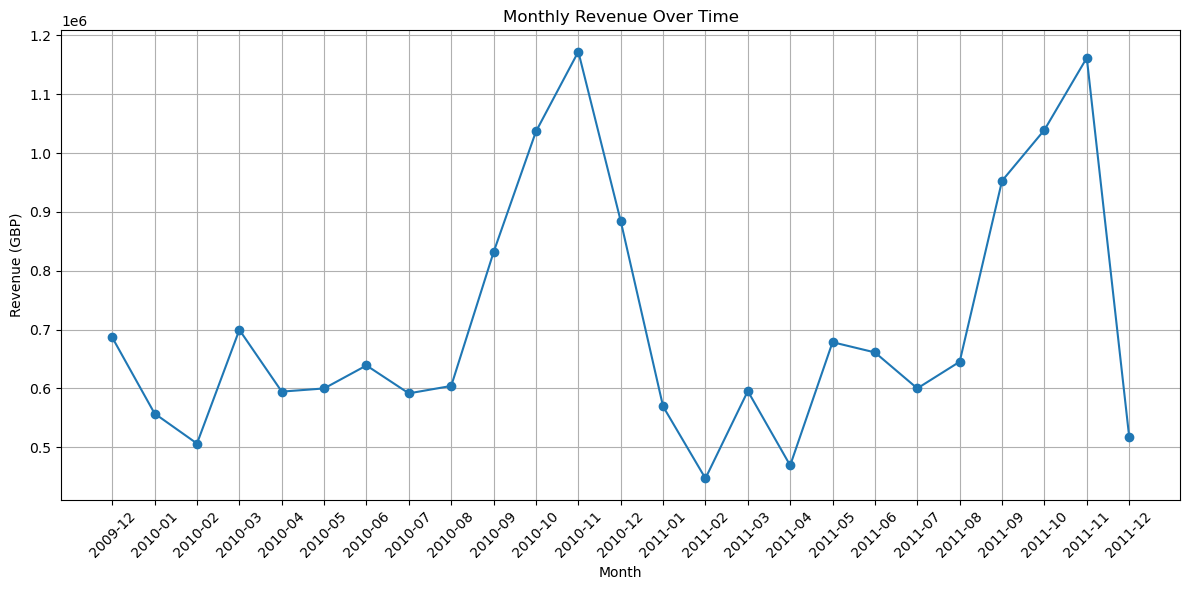

In [9]:
# Baseline line chart — minimal, no styling
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


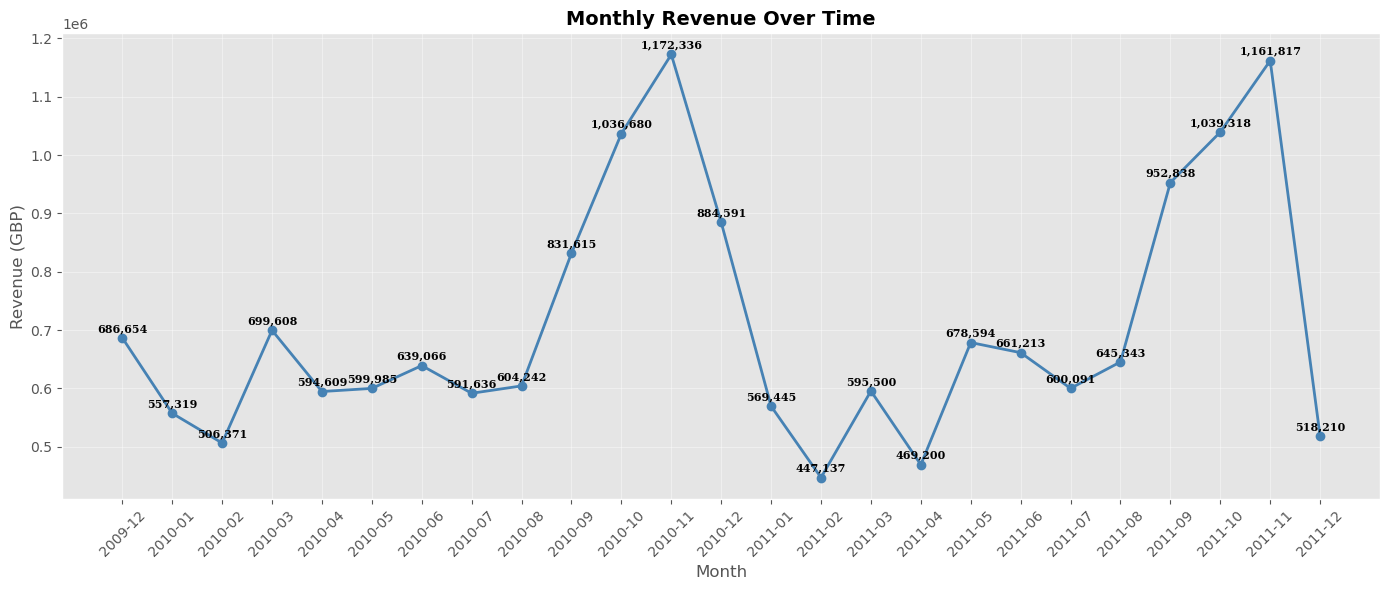

In [10]:
# Styled line chart with value annotations on each data point

# fontdict controls the text style for plt.text()
font = {'family': 'serif', 'color': 'black', 'weight': 'bold', 'size': 8}

with plt.style.context('ggplot'):  # scoped style — does not bleed to other cells
    plt.figure(figsize=(14, 6), facecolor='white')
    plt.plot(monthly_revenue.index, monthly_revenue.values,
             marker='o', color='steelblue', linewidth=2)

    # Annotate each point — offset y by 1 so 0,000text sits above the marker
    for i, value in enumerate(monthly_revenue.values):
        plt.text(monthly_revenue.index[i], value + 10_000,
                 f'{int(value):,}', ha='center', fontdict=font)

    plt.title('Monthly Revenue Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Revenue (GBP)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, alpha=0.4)
    plt.show()


**Key Matplotlib concepts:**

| Function | Purpose |
|----------|---------|
| `plt.figure(figsize=(w, h))` | Create canvas — width and height in inches |
| `plt.plot(x, y, marker='o')` | Draw line with circle markers |
| `plt.text(x, y, label)` | Annotate a point with a text label |
| `plt.style.context('ggplot')` | Scoped style — does not affect other cells |
| `plt.tight_layout()` | Prevents labels from being clipped at edges |
| `plt.grid(True, alpha=0.4)` | Light grid — alpha controls transparency |

**Marker reference:** `'o'` circle · `'s'` square · `'D'` diamond · `'^'` triangle · `'x'` cross · `'+'` plus


---
## 4. Matplotlib — Bar Chart: Top 10 Countries by Revenue

**When to use:** Comparing discrete categories (countries, products, segments).  
Height = magnitude — immediately clear which is largest.

**Business Question:** *Which countries generate the most revenue?*


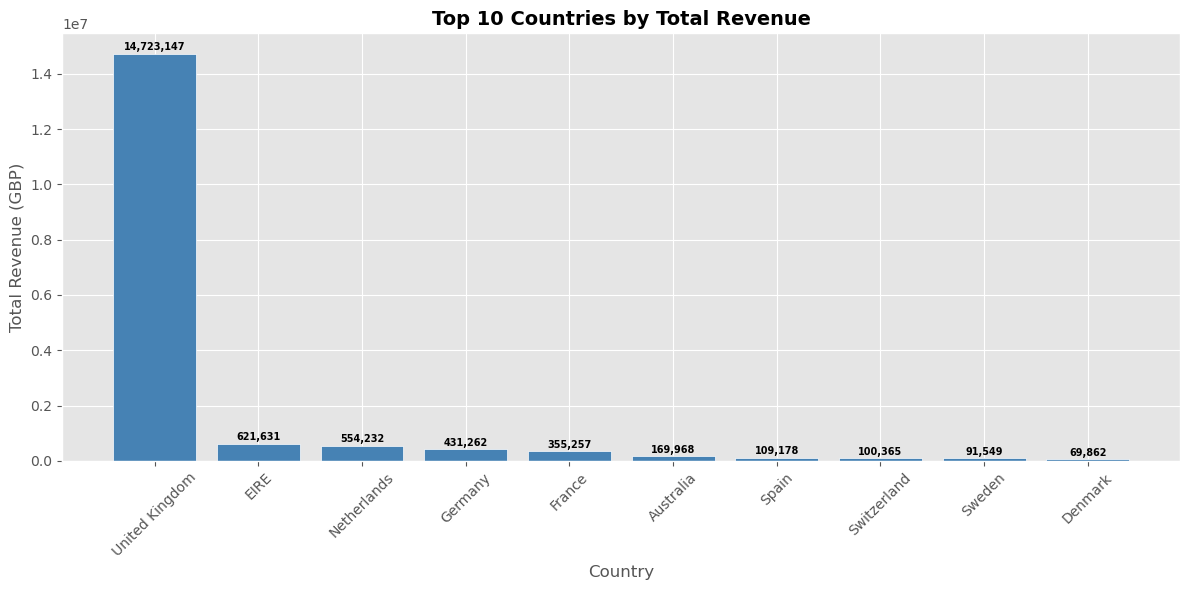

In [11]:
# Group by country, sum revenue, sort descending, take top 10
country_revenue = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

with plt.style.context('ggplot'):
    plt.figure(figsize=(12, 6), facecolor='white')
    bars = plt.bar(country_revenue.index, country_revenue.values,
                   color='steelblue', edgecolor='white')

    # Add value label above each bar
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # x: centre of bar
            bar.get_height() + 50_000,           # y: just above top of bar
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=7, fontweight='bold'
        )

    plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
    plt.xlabel('Country')
    plt.ylabel('Total Revenue (GBP)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


---
## 5. Matplotlib — Scatter Plot: Quantity vs Revenue

**When to use:** Exploring the relationship between two continuous variables.  
Reveals clusters, outliers, and correlation direction.

**Business Question:** *Does ordering more items always generate more revenue, or do high-price low-quantity orders exist?*

> **Why sample?** The cleaned dataset has 805K rows. Rendering 805K scatter points is slow and illegible.  
> `df.sample(1000, random_state=1)` gives a representative subset.  
> `random_state=1` ensures the same 1,000 rows are selected every run (reproducibility).


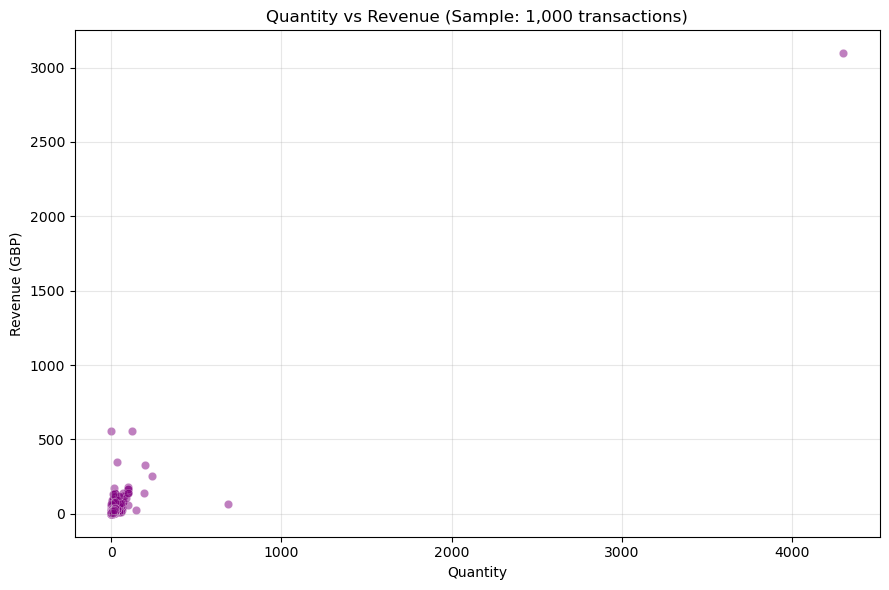

In [12]:
# Sample 1,000 rows for scatter — reproducible via random_state
sample_df = df.sample(1000, random_state=1)

plt.figure(figsize=(9, 6))
plt.scatter(
    sample_df['Quantity'],
    sample_df['Revenue'],
    alpha=0.5,          # transparency — overlapping points remain visible
    color='purple',
    edgecolors='white',
    linewidths=0.3
)
plt.xlabel('Quantity')
plt.ylabel('Revenue (GBP)')
plt.title('Quantity vs Revenue (Sample: 1,000 transactions)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Matplotlib — Subplots: Revenue and Quantity Side-by-Side

**When to use:** Comparing two related metrics on a shared time axis.  
`sharex=True` syncs the x-axis so months align perfectly between charts.

**Business Question:** *Do revenue spikes match volume spikes, or are they driven by price?*

**Subplot indexing pattern:**
```python
plt.subplots(2, 1)  ->  axs[0], axs[1]       # 2 rows, 1 col
plt.subplots(2, 2)  ->  axs[0,0], axs[0,1]   # 2 rows, 2 cols
                         axs[1,0], axs[1,1]
```
Use `axs[i].set_title()` not `plt.title()` — `plt.title()` targets the *last active* axes only.


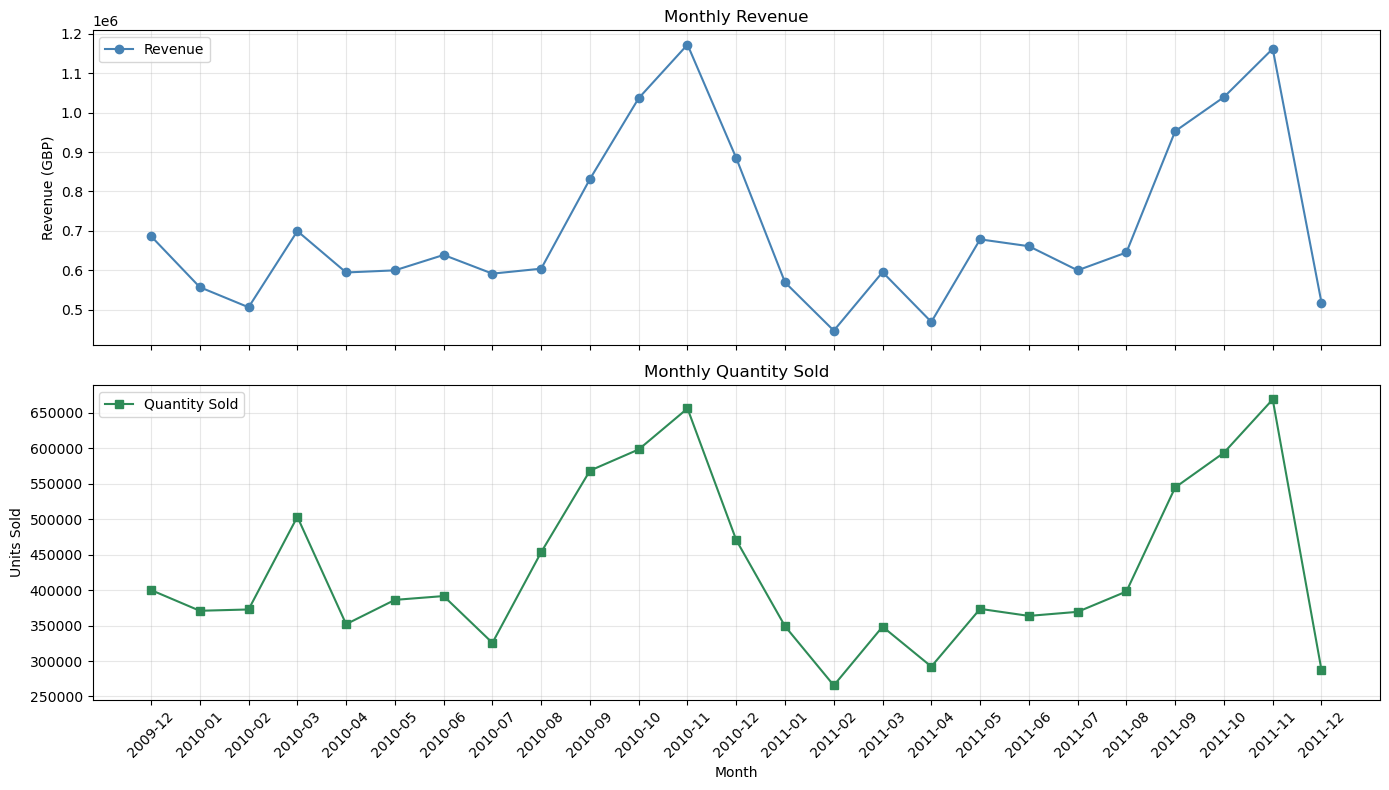

In [13]:
monthly_quantity = df.groupby('Month')['Quantity'].sum().sort_index()

# nrows=2, ncols=1 -> 2 charts stacked vertically
# sharex=True -> both charts share the same x-axis ticks
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

# Top chart: Revenue
axs[0].plot(monthly_revenue.index, monthly_revenue.values,
            marker='o', color='steelblue', label='Revenue')
axs[0].set_title('Monthly Revenue')
axs[0].set_ylabel('Revenue (GBP)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Bottom chart: Quantity
axs[1].plot(monthly_quantity.index, monthly_quantity.values,
            marker='s', color='seagreen', label='Quantity Sold')
axs[1].set_title('Monthly Quantity Sold')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Units Sold')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 7. Saving Figures

`plt.savefig()` must be called **before** `plt.show()`.  
After `show()` the figure buffer is cleared and saving produces a blank image.

- `dpi=300` — high resolution, suitable for reports and presentations
- `dpi=100` — fine for web and notebooks
- `bbox_inches='tight'` — trims extra whitespace around the figure


In [14]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=45)
plt.tight_layout()

# Save BEFORE show() — after show() the figure is cleared
plt.savefig('monthly_revenue_plot.png', dpi=300, bbox_inches='tight')
plt.close()   # free memory explicitly
print('Saved: monthly_revenue_plot.png')


Saved: monthly_revenue_plot.png


---
## 8. Seaborn: Statistical Data Visualization

Seaborn is built **on top of Matplotlib**. It handles statistical plots with cleaner syntax and better defaults.

| | Matplotlib | Seaborn |
|--|--|--|
| Control | Maximum — every pixel | High-level sensible defaults |
| Best for | Custom, publication figures | Statistical EDA, quick patterns |
| Syntax | `plt.plot(x, y)` | `sns.histplot(data=df, x='col')` |

**Three-step Seaborn pattern (always):**
```python
plt.figure(figsize=(12, 6))   # 1. Canvas — Matplotlib
sns.histplot(...)              # 2. Chart  — Seaborn draws onto the Matplotlib canvas
plt.show()                     # 3. Render — Matplotlib
```


---
## 9. Seaborn — Histogram + KDE: Distribution of Quantity

**Business Question:** *What quantity range do most transactions fall in? Is ordering behaviour concentrated or spread out?*

### Histogram
Groups data into equal-width **bins** and counts values per bin.  
With `bins=10`: the range 1–99 is split into 10 groups (0–10, 11–20 ... 91–99).  
Each bar height = number of invoices in that bin.

### KDE (Kernel Density Estimate)
A smooth curve fitted over the histogram. Shows **probability density** — where values are most likely to appear.  
- Higher peak = more transactions clustered in that quantity range  
- Important: **density ≠ probability** directly. But higher density = higher probability of observing a value there.


In [15]:
# Filter: keep only 'normal' quantities (1-99)
# This removes bulk wholesale orders (>100 units) that are extreme outliers
df_quantity = df[(df['Quantity'] > 0) & (df['Quantity'] < 100)]
print(f'Rows after filter: {df_quantity.shape[0]:,}')  # 792,377


Rows after filter: 792,377


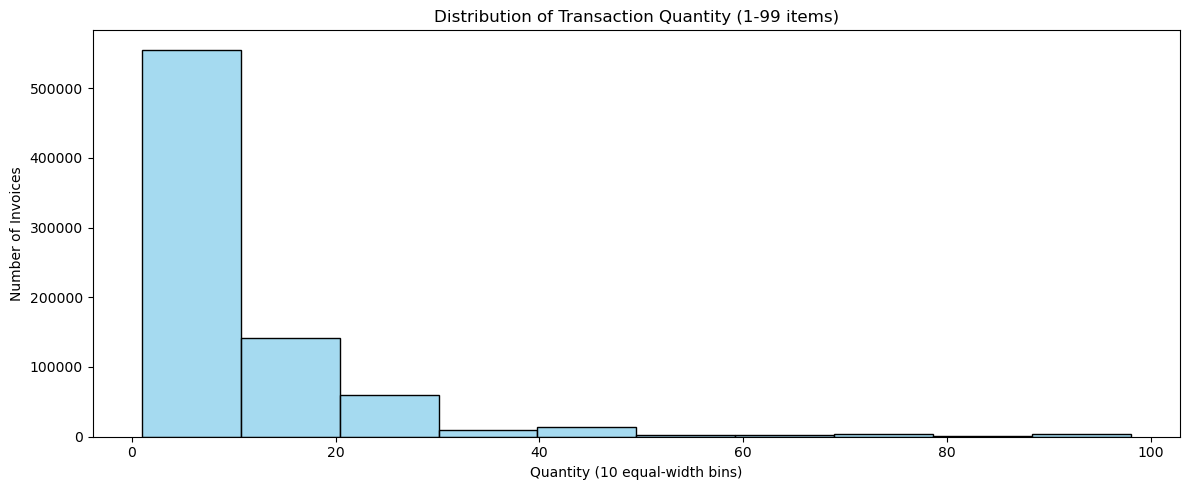

In [16]:
# Histogram only — shows count of invoices per quantity bin
plt.figure(figsize=(12, 5))
sns.histplot(df_quantity['Quantity'], bins=10, kde=False, color='skyblue')
plt.title('Distribution of Transaction Quantity (1-99 items)')
plt.xlabel('Quantity (10 equal-width bins)')
plt.ylabel('Number of Invoices')
plt.tight_layout()
plt.show()


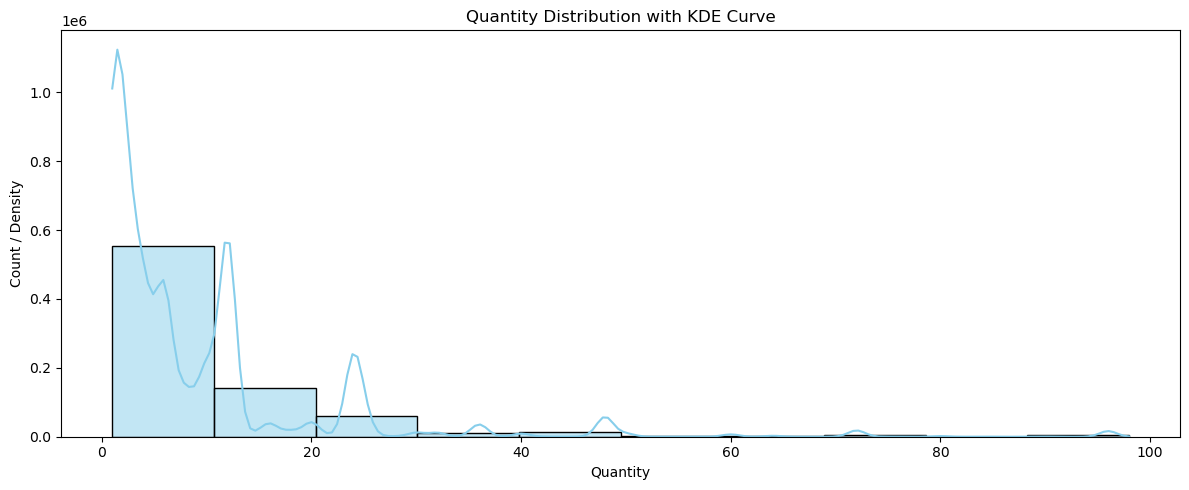

In [17]:
# Histogram + KDE overlay — kde=True adds the smooth probability density curve
plt.figure(figsize=(12, 5))
sns.histplot(df_quantity['Quantity'], bins=10, kde=True, color='skyblue')
plt.title('Quantity Distribution with KDE Curve')
plt.xlabel('Quantity')
plt.ylabel('Count / Density')
plt.tight_layout()
plt.show()


In [ ]:
# Pure KDE — smooth density curve without the histogram bars
plt.figure(figsize=(12, 5))
sns.kdeplot(df_quantity['Quantity'], fill=True, color='steelblue', alpha=0.6)
plt.title('KDE: Probability Density of Transaction Quantity')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()


**Business insight:** The sharp peak at low quantities (1-10) tells us most customers are retail buyers, not wholesale.  
The long right tail shows a small number of bulk orders exist but are rare.


---
## 10. Seaborn — Boxplot: Revenue Distribution by Month

**What a boxplot shows (5-number summary):**
```
    Whisker top  <- max non-outlier value (Q3 + 1.5 * IQR)
    +----------+
    |    Q3    |  <- 75th percentile
    |   IQR    |  <- Interquartile Range = Q3 - Q1  (box height)
    |  median  |  <- 50th percentile  (line inside box)
    |    Q1    |  <- 25th percentile
    +----------+
    Whisker btm  <- min non-outlier value (Q1 - 1.5 * IQR)
    o  o  o      <- Outliers: individual dots beyond the whiskers
```

**Business use:** Instantly compare revenue spread across months.  
Tall box = high variance that month. Outlier dots = unusually large orders.


Rows in this range: 463


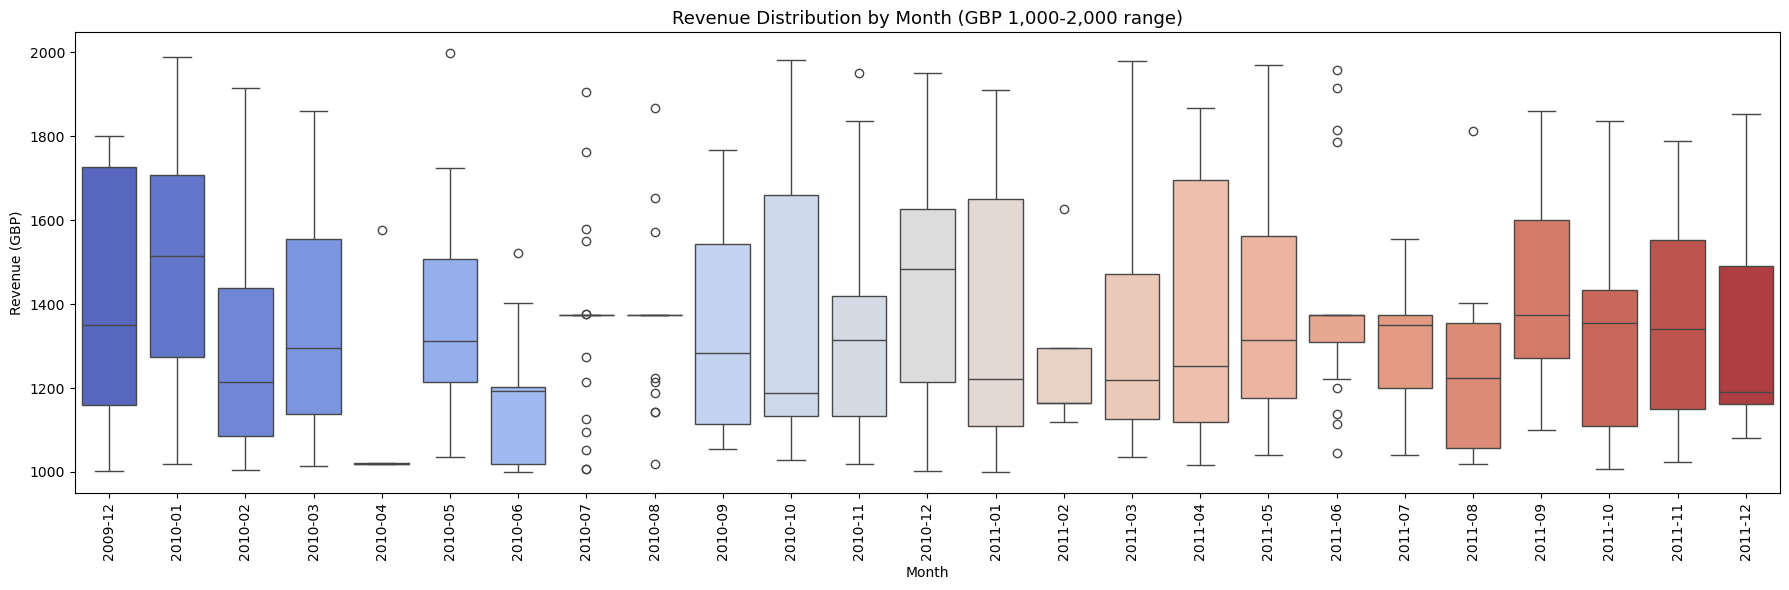

In [18]:
# Filter to a focused revenue range for a readable boxplot
# Full range has extreme outliers that compress all boxes to a sliver
df_revenue_sample = df[(df['Revenue'] > 1000) & (df['Revenue'] < 2000)]
print(f'Rows in this range: {df_revenue_sample.shape[0]:,}')  # 463

plt.figure(figsize=(18, 6))
sns.boxplot(data=df_revenue_sample, x='Month', y='Revenue', palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Revenue Distribution by Month (GBP 1,000-2,000 range)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')
plt.tight_layout()
plt.show()


---
## 11. Seaborn — Grouped Barplot: Monthly Revenue by Top 5 Countries

**Grouped bar:** Multiple bars per x-tick, each colored by `hue` category.  
Lets you compare countries *within* each month simultaneously.

**Business Question:** *Does the UK consistently dominate revenue, or do other countries catch up seasonally?*


In [19]:
# Identify top 5 countries by number of transactions (not by revenue)
top_countries = df['Country'].value_counts().head(5).index.tolist()
print('Top 5 countries by transaction count:', top_countries)

# Filter to those 5 countries only
df_top = df[df['Country'].isin(top_countries)].copy()

# Aggregate: sum revenue per Country per Month
grouped = df_top.groupby(['Country', 'Month'])['Revenue'].sum().reset_index()
print(f'Grouped shape: {grouped.shape}')  # (125, 3) — 25 months x 5 countries
grouped.head()


Top 5 countries by transaction count: ['United Kingdom', 'Germany', 'EIRE', 'France', 'Netherlands']
Grouped shape: (125, 3)


,Country,Month,Revenue
0,EIRE,2009-12,18170.46
1,EIRE,2010-01,65031.41
2,EIRE,2010-02,20206.46
3,EIRE,2010-03,22989.46
4,EIRE,2010-04,20668.08


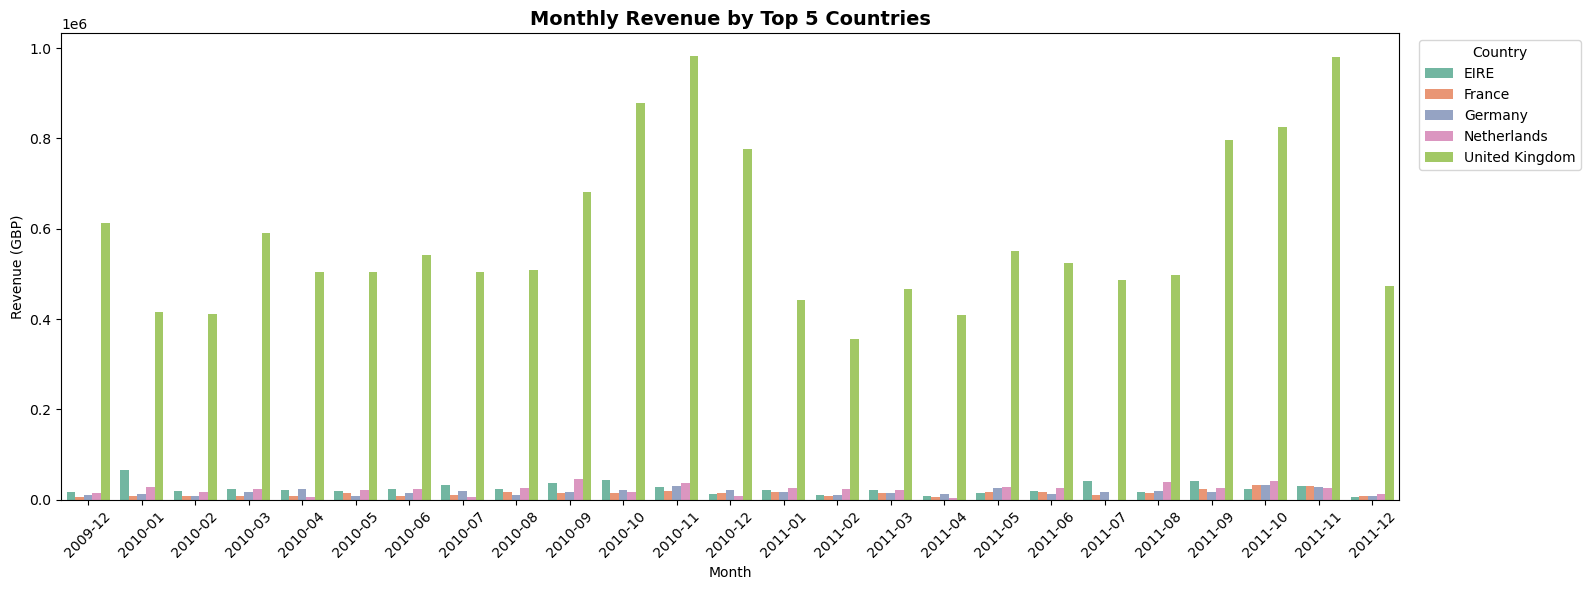

In [20]:
plt.figure(figsize=(16, 6))
sns.barplot(data=grouped, x='Month', y='Revenue', hue='Country', palette='Set2')
plt.title('Monthly Revenue by Top 5 Countries', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (GBP)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## 12. Seaborn — Pairplot: Multi-Variable Relationships

`sns.pairplot()` generates a grid of charts in one call:
- **Diagonal:** distribution of each variable on its own
- **Off-diagonal:** scatter plot of every pair of variables

**When to use:** Before building ML models, to spot correlations and decide which features are informative.


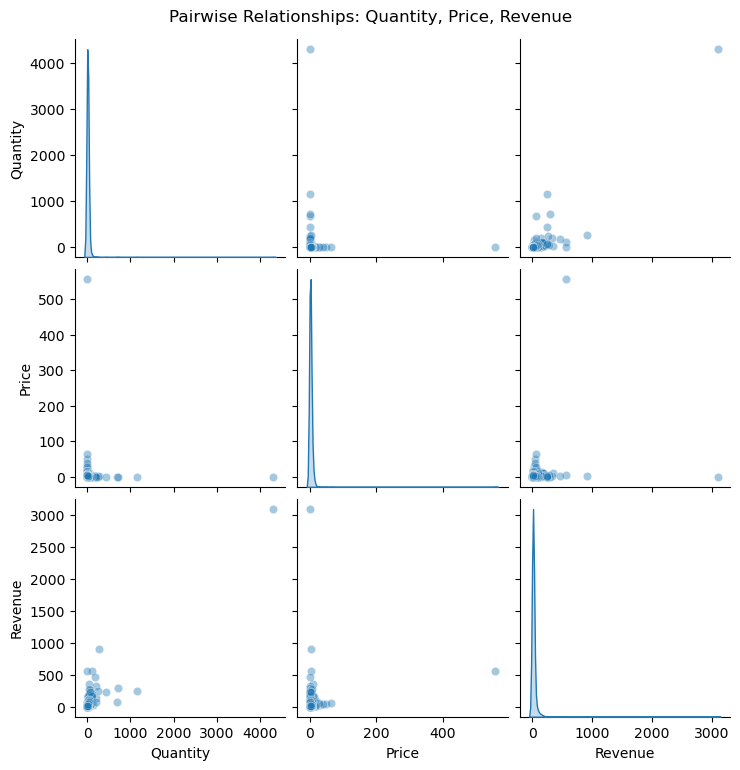

In [21]:
# Sample for performance — pairplot on 800K rows would be very slow
df_sample = df[['Quantity', 'Price', 'Revenue']].sample(2000, random_state=1)

# diag_kind='kde' -> smooth density on the diagonal (cleaner than histogram)
# plot_kws applies to the scatter cells (alpha = transparency)
g = sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairwise Relationships: Quantity, Price, Revenue', y=1.02)
plt.show()


**Reading the grid:**

| Pair | Pattern | Interpretation |
|------|---------|----------------|
| Quantity vs Revenue | Positive slope | More items ordered → higher revenue (as expected) |
| Price vs Revenue | Mild positive | High-price items drive revenue even at low quantity |
| Price vs Quantity | Flat / scattered | Price and quantity ordered are mostly independent |

> **Correlation sign:** positive slope = positive correlation (> 0).  
> One variable up while the other goes down = negative correlation (< 0).  
> No visible pattern = correlation near 0.


---
## 13. Seaborn — Heatmap: Correlation Matrix

**Correlation values range from -1 to +1:**

| Value | Meaning |
|-------|---------|
| +1.0 | Perfect positive — both variables increase together |
| 0.0 | No linear relationship |
| -1.0 | Perfect negative — one increases as the other decreases |

**Business use:** Before ML modelling, identify multicollinearity.  
If two features correlate at 0.95+, they carry the same information — you likely only need one.


In [22]:
# Use a larger sample for a stable correlation estimate
df_sample = df[['Quantity', 'Price', 'Revenue']].sample(5000, random_state=1)

# .corr() computes pairwise Pearson correlation for all numeric columns
corr_matrix = df_sample[['Quantity', 'Price', 'Revenue']].corr()
print(corr_matrix)


          Quantity     Price   Revenue
Quantity  1.000000 -0.031283  0.705203
Price    -0.031283  1.000000  0.115049
Revenue   0.705203  0.115049  1.000000


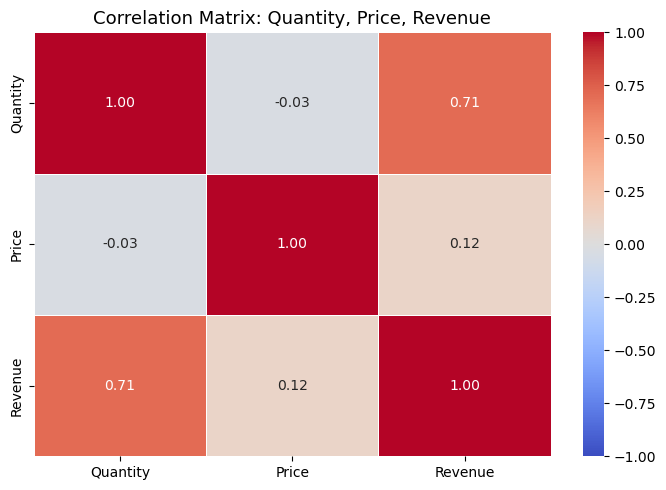

In [23]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,       # show numeric value inside each cell
    cmap='coolwarm',  # blue = negative, white = zero, red = positive
    fmt='.2f',        # 2 decimal places
    linewidths=0.5,   # grid lines between cells
    vmin=-1, vmax=1   # fix colour scale to the full [-1, 1] range
)
plt.title('Correlation Matrix: Quantity, Price, Revenue', fontsize=13)
plt.tight_layout()
plt.show()


**Expected results from this dataset:**
- `Quantity vs Revenue` ≈ 0.71 — strong positive (more items → more revenue)
- `Price vs Revenue` ≈ 0.12 — weak positive (price plays a smaller role at transaction level)
- `Price vs Quantity` ≈ -0.03 — near zero (price and quantity are essentially independent)


---
## Summary: Chart Selection Guide

| Chart | Use When | Seaborn | Matplotlib |
|-------|----------|---------|------------|
| Line | Trends over time | `sns.lineplot()` | `plt.plot()` |
| Bar | Compare discrete categories | `sns.barplot()` | `plt.bar()` |
| Scatter | Relationship between 2 numeric vars | `sns.scatterplot()` | `plt.scatter()` |
| Histogram | Distribution of 1 numeric var | `sns.histplot()` | `plt.hist()` |
| KDE | Smooth probability density | `sns.kdeplot()` | — |
| Boxplot | Distribution + outliers per category | `sns.boxplot()` | — |
| Pairplot | All pairwise relationships at once | `sns.pairplot()` | — |
| Heatmap | Correlation or confusion matrix | `sns.heatmap()` | — |

---

## Principles of Good Visualization

1. **Clarity** — a recruiter or stakeholder should understand the chart in under 5 seconds
2. **Proper scale** — never truncate axes to artificially exaggerate differences
3. **Minimalism** — remove chart junk (unnecessary borders, gridlines, colours)
4. **Label everything** — title, x-axis, y-axis, units, legend
5. **Colour wisely** — colour should encode meaning, not decoration
6. **Choose the right chart** — bars for categories, lines for time, scatter for relationships

---
*Part of an 8-month Data Engineering & Data Science self-study curriculum.*  
*Dataset: UCI Online Retail II — UK-based e-commerce, 2009-2011.*
